# Retinal vessel segmentation

Per-pixel binary classification: vessel vs background.

## Outline

1. Imports
2. Config
3. Data loading (HRF / STARE / CHASE)
4. EDA — RGB channels
5. Metrics
6. **Method 1 — image processing** (mandatory)
7. **Method 2 — classical ML on patches** (4.0)
8. **Method 3 — U-Net** (5.0)
9. Comparison
10. Report notes

## 1. Imports

In [ ]:
# !pip install -r requirements.txt

In [9]:
import os, glob, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import cv2
from skimage import exposure, morphology
from skimage.filters import frangi, threshold_otsu

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.metrics import geometric_mean_score, sensitivity_score, specificity_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

print(f'numpy {np.__version__} | opencv {cv2.__version__} | torch {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}')

numpy 2.4.5 | opencv 4.13.0 | torch 2.12.0
CUDA: False | MPS: True


## 2. Config

In [10]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR    = PROJECT_DIR / 'data'
IMG_DIR     = DATA_DIR / 'images'
GT_DIR      = DATA_DIR / 'manual1'
FOV_DIR     = DATA_DIR / 'mask'
MODEL_DIR   = PROJECT_DIR / 'models'
RESULT_DIR  = PROJECT_DIR / 'results'
for d in (DATA_DIR, IMG_DIR, GT_DIR, FOV_DIR, MODEL_DIR, RESULT_DIR):
    d.mkdir(parents=True, exist_ok=True)

PATCH_SIZE        = 5
UNET_PATCH        = 48
DOWNSCALE         = 0.5
TEST_FRACTION     = 1/3
UNDERSAMPLE_RATIO = 1.0

DEVICE = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')
print('Device:', DEVICE)

Device: mps


## 3. Data loading

Drop HRF files into `data/images/`, `data/manual1/`, `data/mask/`. Matching is done by file stem.

In [8]:
IMG_EXT = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.ppm'}
MASK_EXT = {'.gif', '.png', '.tif', '.tiff', '.ppm'}

def list_samples(img_dir=IMG_DIR, gt_dir=GT_DIR, fov_dir=FOV_DIR):
    imgs = {p.stem: p for p in img_dir.glob('*') if p.suffix.lower() in IMG_EXT}
    gts  = {p.stem: p for p in gt_dir.glob('*')  if p.suffix.lower() in MASK_EXT}
    fovs = {p.stem[:-5]: p for p in fov_dir.glob('*') if p.suffix.lower() in MASK_EXT} # remove '_mask' suffix
    return [(imgs[k], gts[k], fovs[k]) for k in sorted(set(imgs) & set(gts) & set(fovs))]

def load_sample(img_path, gt_path, fov_path, downscale=DOWNSCALE):
    img = np.array(Image.open(img_path).convert('RGB'))
    gt  = np.array(Image.open(gt_path).convert('L')) > 127
    fov = np.array(Image.open(fov_path).convert('L')) > 127
    if downscale and downscale != 1.0:
        size = (int(img.shape[1] * downscale), int(img.shape[0] * downscale))
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
        gt  = cv2.resize(gt.astype(np.uint8),  size, interpolation=cv2.INTER_NEAREST).astype(bool)
        fov = cv2.resize(fov.astype(np.uint8), size, interpolation=cv2.INTER_NEAREST).astype(bool)
    return img, gt, fov

samples = list_samples()
print(f'{len(samples)} samples found')

45 samples found


## 4. EDA — RGB channels

The green channel typically shows the highest vessel/background contrast.

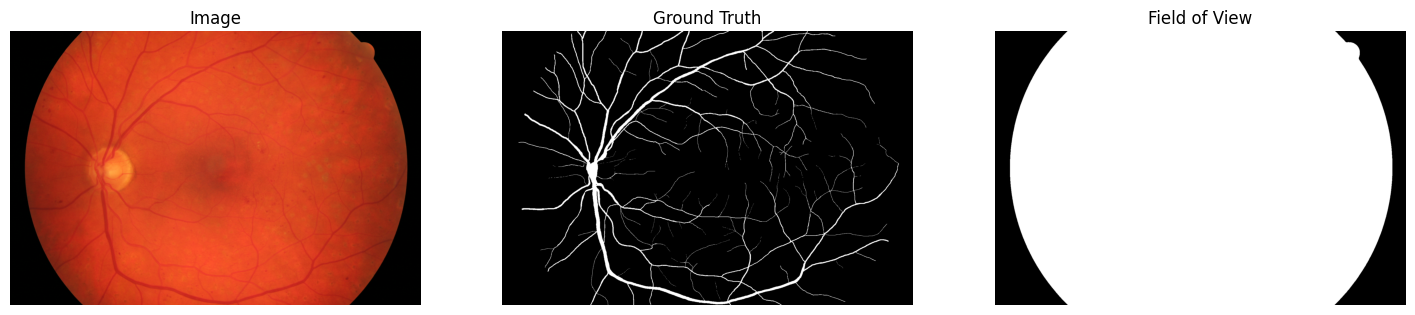

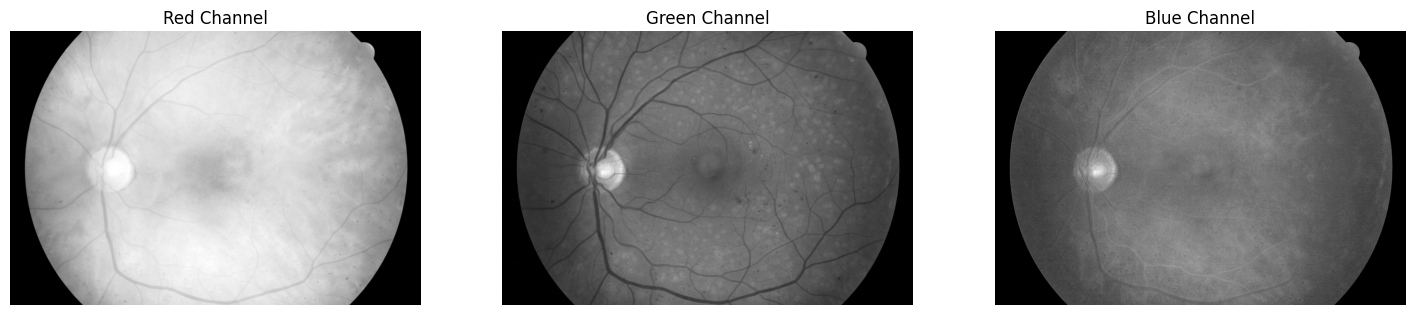

In [14]:
# TODO: load samples[0], plot image / gt / fov, then R, G, B grayscale


# Plot first sample
img, gt, fov = load_sample(*samples[0])
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img); plt.title('Image'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(gt, cmap='gray'); plt.title('Ground Truth'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(fov, cmap='gray'); plt.title('Field of View'); plt.axis('off')

# Plot R, G, B channels
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1); plt.imshow(img[..., 0], cmap='gray'); plt.title('Red Channel'); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(img[..., 1], cmap='gray'); plt.title('Green Channel'); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(img[..., 2], cmap='gray'); plt.title('Blue Channel'); plt.axis('off')
plt.show()

## 5. Metrics

Vessel = positive. Imbalanced data, so report G-mean and F1 alongside accuracy.

In [15]:
def evaluate(y_true, y_pred, fov_mask=None):
    if fov_mask is not None:
        y_true, y_pred = y_true[fov_mask], y_pred[fov_mask]
    y_true = y_true.ravel().astype(int)
    y_pred = y_pred.ravel().astype(int)
    sens = sensitivity_score(y_true, y_pred)
    spec = specificity_score(y_true, y_pred)
    return {
        'accuracy':    accuracy_score(y_true, y_pred),
        'sensitivity': sens,
        'specificity': spec,
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'g_mean':      geometric_mean_score(y_true, y_pred),
        'arith_mean':  (sens + spec) / 2,
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }

def metrics_to_row(m, name):
    return {'name': name, **{k: v for k, v in m.items() if k != 'confusion_matrix'}}

## 6. Method 1 — image processing


### 6.1. Pipeline: preprocess → Frangi → Otsu → morphology.

In [36]:
def preprocess(rgb):
    green = rgb[..., 1] # green channel has best contrast for vessels
    eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(green)
    eq = exposure.adjust_gamma(eq, gamma=1.2)
    return cv2.medianBlur(eq, 5)

In [39]:
def frangi_segment(gray, fov_mask=None, sigmas=np.arange(1, 3, 1), beta=0.5, gamma=2.5, otsu_mult=0.5):
    # the lower the beta, the more sensitive to low-contrast vessels (but also noise)
    # the lower the gamma, the more sensitive to wider vessels (but also noise)
    # the lower the sigmas, the more sensitive to finer vessels (but also noise)
    response = frangi(gray, sigmas=list(sigmas), beta=beta, gamma=gamma, black_ridges=True)
    # erode FOV to drop the bright disk border that Frangi picks up
    if fov_mask is not None:
        response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
    thresh = threshold_otsu(response[response > 0]) if response.max() > 0 else 0
    # lower the threshold to increase sensitivity (but also noise)
    return response > (thresh * otsu_mult), response

def postprocess(binary, min_size=10):
    # lower the min_size to remove smaller objects (but also noise)
    out = morphology.remove_small_objects(binary, min_size=min_size)
    return morphology.remove_small_holes(out, area_threshold=min_size)

def ip_pipeline(rgb, fov_mask, sigmas=np.arange(1, 3, 1), beta=0.5, gamma=2.5, otsu_mult=0.5, min_size=10):
    seg, _ = frangi_segment(preprocess(rgb), fov_mask=fov_mask, sigmas=sigmas, beta=beta, gamma=gamma, otsu_mult=otsu_mult)
    return postprocess(seg, min_size=min_size)

### 6.2. Finding best parameters 
#### grid search to find best f1 - because of imbalanced classes

In [40]:
import itertools
import pandas as pd
from tqdm.auto import tqdm

# Hyperparameters to tune
param_grid = {
    'max_sigma': [2, 3, 4],
    'gamma': [2, 5, 15],
    'otsu_mult': [0.3, 0.5, 0.8],
    'min_size': [5, 10, 20]
}

keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

tune_samples = samples[:3] # Subset for faster tuning
results = []
best_f1 = 0
best_params = None

print(f"Starting grid search over {len(combinations)} combinations...")

for params in tqdm(combinations, desc="Tuning hypers"):
    f1_scores = []
    
    for img_p, gt_p, fov_p in tune_samples:
        img, gt, fov = load_sample(img_p, gt_p, fov_p)
        
        # Calculate dynamic sigma range
        sigmas = np.arange(1, params['max_sigma'] + 1, 1)
        
        # Use the parameterized ip_pipeline
        pred = ip_pipeline(img, fov_mask=fov, sigmas=sigmas, gamma=params['gamma'], otsu_mult=params['otsu_mult'], min_size=params['min_size'])
        
        # Evaluate F1-score only within Field Of View mask
        f1 = f1_score(gt[fov].astype(int), pred[fov].astype(int), zero_division=0)
        f1_scores.append(f1)
        
    mean_f1 = np.mean(f1_scores)
    results.append({'mean_f1': mean_f1, **params})
    
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = params

print(f"\nBest F1-score: {best_f1:.4f}")
print(f"Best parameters: {best_params}\n")

# Display Top 5 combinations
df_tune = pd.DataFrame(results).sort_values('mean_f1', ascending=False)
display(df_tune.head())

Starting grid search over 81 combinations...


Tuning hypers:   0%|          | 0/81 [00:00<?, ?it/s]

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16


Best F1-score: 0.6677
Best parameters: {'max_sigma': 4, 'gamma': 2, 'otsu_mult': 0.5, 'min_size': 20}



/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed sma

,mean_f1,max_sigma,gamma,otsu_mult,min_size
59,0.667702,4,2,0.5,20
32,0.667099,3,2,0.5,20
5,0.653719,2,2,0.5,20
58,0.651002,4,2,0.5,10
31,0.650526,3,2,0.5,10


### 6.3. Visualisation for the selected parameters 

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16

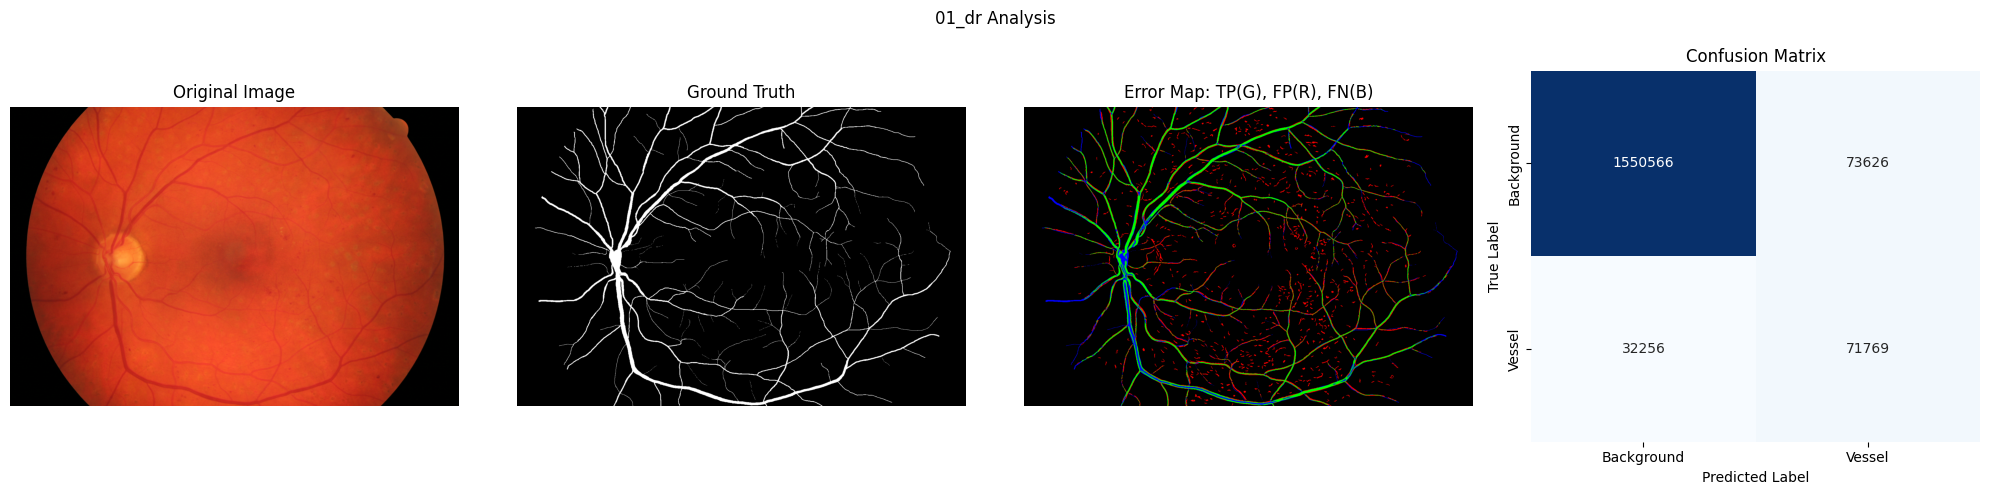

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16

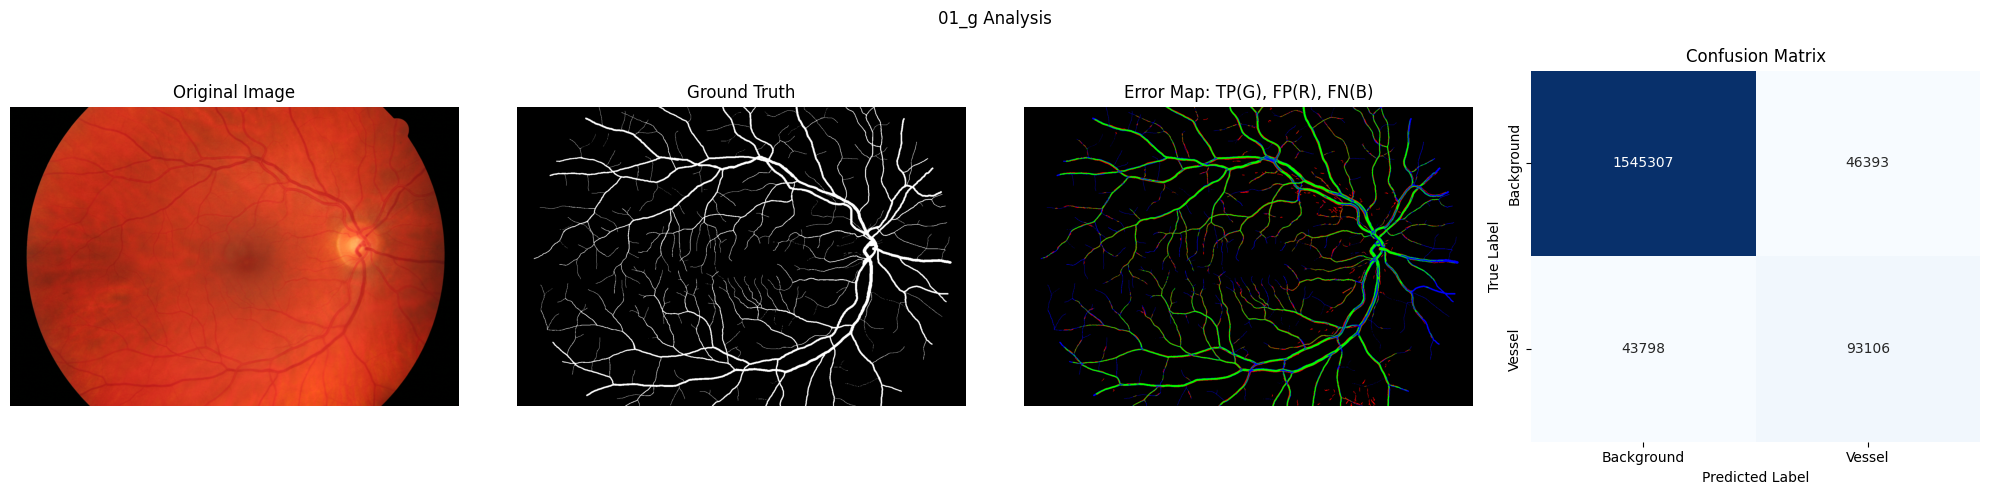

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16

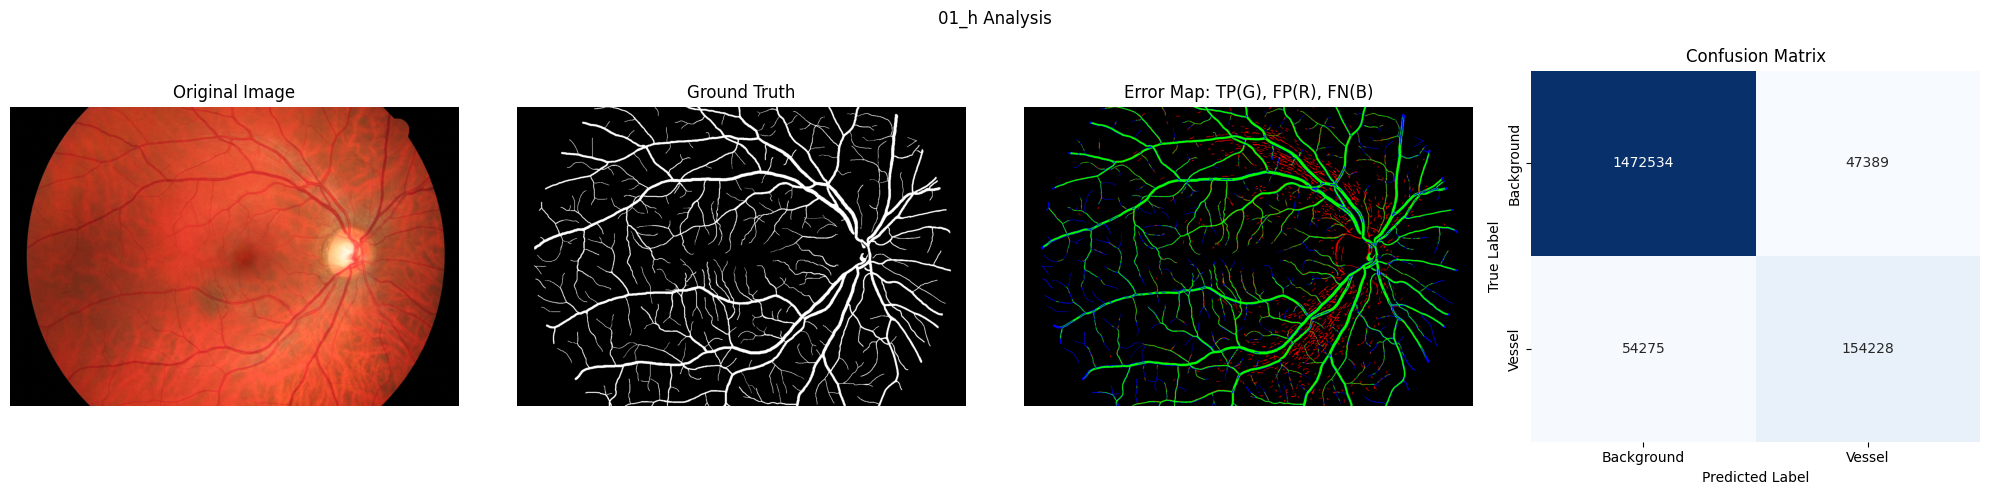

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16

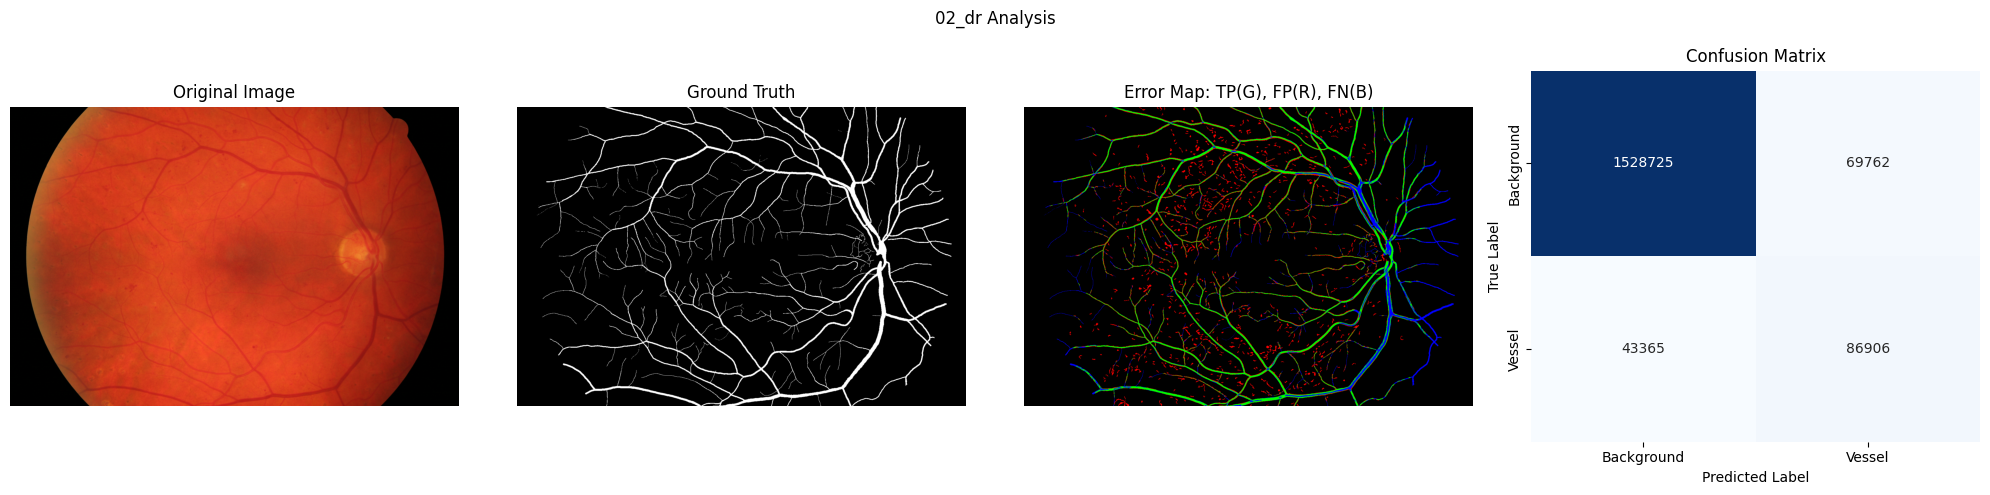

/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  response = response * morphology.binary_erosion(fov_mask, morphology.disk(10))
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:15: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out = morphology.remove_small_objects(binary, min_size=min_size)
/var/folders/3r/tj62hbfx2s36007ms4gcy0l40000gn/T/ipykernel_51008/2433950380.py:16

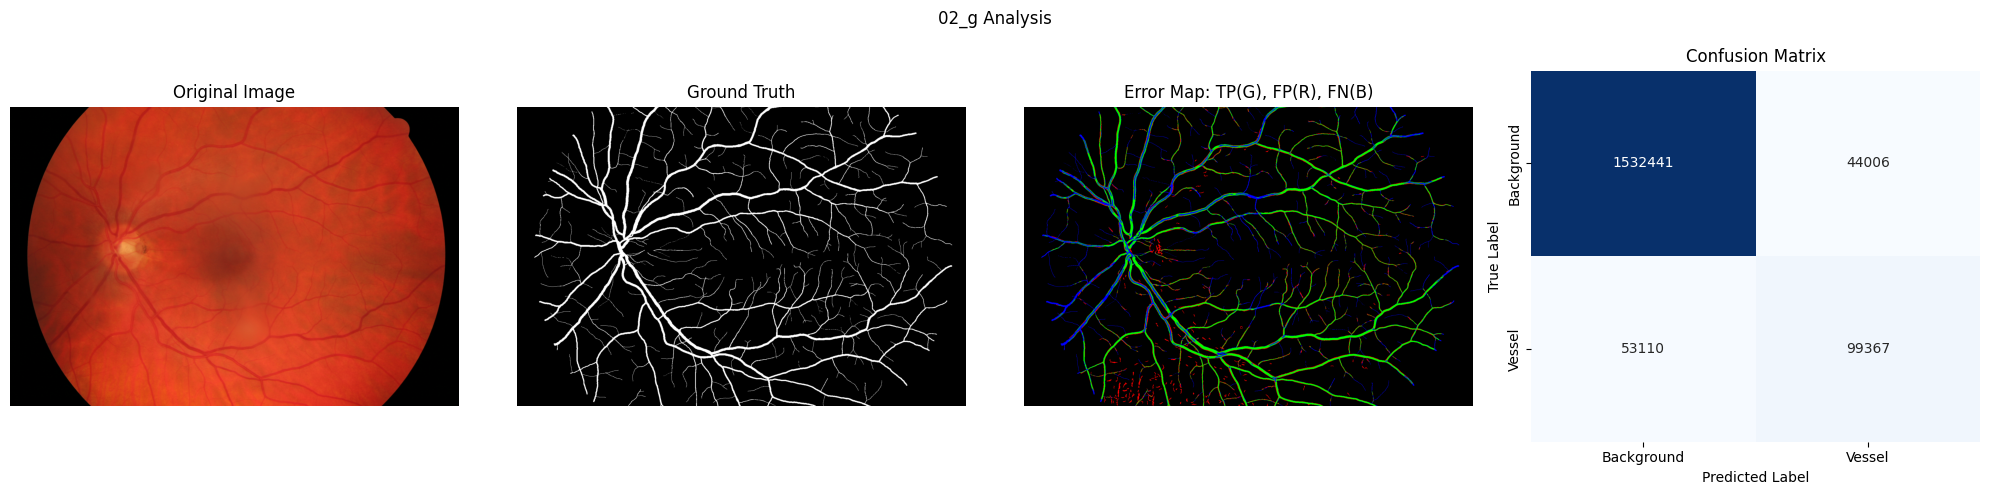

,name,accuracy,sensitivity,specificity,precision,f1,g_mean,arith_mean
0,01_dr,0.938733,0.689921,0.954669,0.493614,0.575487,0.811570,0.822295
1,01_g,0.947824,0.680082,0.970853,0.667431,0.673697,0.812564,0.825468
2,01_h,0.941181,0.739692,0.968821,0.764955,0.752112,0.846540,0.854257
3,02_dr,0.934562,0.667117,0.956357,0.554714,0.605745,0.798750,0.811737
4,02_g,0.943829,0.651685,0.972085,0.693066,0.671739,0.795923,0.811885


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ip_rows = []
for img_p, gt_p, fov_p in samples[:5]:
    img, gt, fov = load_sample(img_p, gt_p, fov_p)
    pred = ip_pipeline(img, fov, sigmas=np.arange(1, 4, 1), beta=0.5, gamma=2, otsu_mult=0.5, min_size=20)
    
    # Przechwytujemy pełną odpowiedź z validate (zeby miec confusion matrix przed pociachaniem)
    eval_metrics = evaluate(gt, pred, fov_mask=fov)
    ip_rows.append(metrics_to_row(eval_metrics, img_p.stem))
    
    plt.figure(figsize=(20, 5))

    # 1. Original image
    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    # 2. Ground truth mask
    plt.subplot(1, 4, 2)
    plt.imshow(gt, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    # 3. Error Map overlay
    plt.subplot(1, 4, 3)
    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    error_map[(pred == 1) & (gt == 1)] = [0, 255, 0]   # True Positive -> green
    error_map[(pred == 1) & (gt == 0)] = [255, 0, 0]   # False Positive -> red
    error_map[(pred == 0) & (gt == 1)] = [0, 0, 255]   # False Negative -> blue
    
    plt.imshow(error_map)
    plt.title('Error Map: TP(G), FP(R), FN(B)')
    plt.axis('off')    
    
    # 4. Confusion Matrix heatmap
    ax = plt.subplot(1, 4, 4)
    sns.heatmap(eval_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Background', 'Vessel'], 
                yticklabels=['Background', 'Vessel'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.suptitle(f"{img_p.stem} Analysis")
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'{img_p.stem}_frangi.png')
    plt.show()
    plt.close()
    
df_ip = pd.DataFrame(ip_rows)
df_ip

## 7. Method 2 — classical ML on patches

For each pixel: take a 5×5 patch, extract features, label from gold mask at the center pixel.

In [ ]:
def patch_features(patch):
    stats = [patch.mean(), patch.std(), patch.var(),
             patch.min(), patch.max(), np.median(patch)]
    hu = cv2.HuMoments(cv2.moments(patch.astype(np.uint8))).flatten()
    # log-scale Hu moments (raw values span many orders of magnitude)
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    return np.array(stats + hu.tolist(), dtype=np.float32)

def extract_dataset(rgb, gt, fov, patch_size=PATCH_SIZE, stride=1, max_pixels=None):
    gray = preprocess(rgb)
    half = patch_size // 2
    padded = np.pad(gray, half, mode='reflect')
    H, W = gray.shape
    coords = [(y, x) for y in range(0, H, stride) for x in range(0, W, stride) if fov[y, x]]
    if max_pixels and len(coords) > max_pixels:
        coords = random.sample(coords, max_pixels)
    X = np.empty((len(coords), 13), dtype=np.float32)
    y = np.empty(len(coords), dtype=np.int8)
    for i, (yy, xx) in enumerate(coords):
        X[i] = patch_features(padded[yy:yy + patch_size, xx:xx + patch_size])
        y[i] = gt[yy, xx]
    return X, y, coords

In [ ]:
# TODO: split samples into train/test; build X_train/y_train and X_test/y_test
# rus = RandomUnderSampler(sampling_strategy=UNDERSAMPLE_RATIO, random_state=SEED)
# X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

In [ ]:
# clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
# clf.fit(X_train_bal, y_train_bal)
# joblib.dump(clf, MODEL_DIR / 'rf.joblib')

In [ ]:
def predict_full_image(clf, rgb, fov, patch_size=PATCH_SIZE, stride=1):
    X, _, coords = extract_dataset(rgb, np.zeros_like(fov), fov,
                                    patch_size=patch_size, stride=stride)
    preds = clf.predict(X)
    out = np.zeros(rgb.shape[:2], dtype=bool)
    for (yy, xx), p in zip(coords, preds):
        out[yy, xx] = bool(p)
    return out

# TODO: run predict_full_image + evaluate on each test sample -> ml_rows

## 8. Method 3 — U-Net

Train on random 48×48 patches, predict full image via sliding window with overlap averaging.

In [ ]:
class RetinaPatchDataset(Dataset):
    def __init__(self, samples, patch_size=UNET_PATCH, patches_per_image=2000, augment=True):
        self.data = [(preprocess(img), gt, fov)
                     for img, gt, fov in (load_sample(*s) for s in samples)]
        self.patch = patch_size
        self.n = patches_per_image * len(self.data)
        self.augment = augment

    def __len__(self): return self.n

    def __getitem__(self, _):
        gray, gt, fov = random.choice(self.data)
        H, W = gray.shape; p = self.patch
        while True:
            y = random.randint(p // 2, H - p // 2 - 1)
            x = random.randint(p // 2, W - p // 2 - 1)
            if fov[y, x]: break
        y0, x0 = y - p // 2, x - p // 2
        ip = gray[y0:y0 + p, x0:x0 + p].astype(np.float32) / 255.0
        gp = gt[y0:y0 + p, x0:x0 + p].astype(np.float32)
        if self.augment:
            if random.random() < 0.5: ip, gp = np.fliplr(ip).copy(), np.fliplr(gp).copy()
            if random.random() < 0.5: ip, gp = np.flipud(ip).copy(), np.flipud(gp).copy()
        return torch.from_numpy(ip).unsqueeze(0), torch.from_numpy(gp).unsqueeze(0)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.d1 = DoubleConv(in_ch, base)
        self.d2 = DoubleConv(base, base * 2)
        self.d3 = DoubleConv(base * 2, base * 4)
        self.bn = DoubleConv(base * 4, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.u3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.u2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.u1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_ch, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2))
        b  = self.bn(self.pool(c3))
        x  = self.u3(torch.cat([self.up3(b), c3], 1))
        x  = self.u2(torch.cat([self.up2(x), c2], 1))
        x  = self.u1(torch.cat([self.up1(x), c1], 1))
        return self.out(x)

In [ ]:
# train_samples, test_samples = train_test_split(samples, test_size=TEST_FRACTION, random_state=SEED)
# loader = DataLoader(RetinaPatchDataset(train_samples), batch_size=64, shuffle=True, num_workers=2)
# model  = UNet().to(DEVICE)
# opt    = torch.optim.Adam(model.parameters(), lr=1e-3)
# loss_fn = nn.BCEWithLogitsLoss()
# TODO: training loop; torch.save(model.state_dict(), MODEL_DIR / 'unet.pt')

In [ ]:
@torch.no_grad()
def predict_unet(model, rgb, patch=UNET_PATCH, stride=None):
    model.eval()
    stride = stride or patch // 2
    gray = preprocess(rgb).astype(np.float32) / 255.0
    H, W = gray.shape
    prob  = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            tile = torch.from_numpy(gray[y:y+patch, x:x+patch]).unsqueeze(0).unsqueeze(0).to(DEVICE)
            prob[y:y+patch, x:x+patch] += torch.sigmoid(model(tile)).squeeze().cpu().numpy()
            count[y:y+patch, x:x+patch] += 1
    prob = np.divide(prob, count, out=np.zeros_like(prob), where=count > 0)
    return prob > 0.5, prob

## 9. Comparison

In [ ]:
# TODO: concat df_ip / df_ml / df_unet with 'method' column; bar plots; side-by-side overlays